# Insurance Risk Advisor — Week 2: Feature Engineering, Modeling & SHAP
**Project:** AI-Powered Insurance Policy Advisor & Risk Explainer  
**Author:** Shubham Maheshwari  
**Input:** `health_insurance_with_segments.csv` (output of Week 1)  
**Goal:** Engineer meaningful features → Train XGBoost → Evaluate → Explain with SHAP

---
## Notebook Structure
1. Setup & Load Processed Data
2. Feature Engineering (domain-driven)
3. Preprocessing Pipeline (encode + scale)
4. Train/Test Split
5. XGBoost Model Training
6. Model Evaluation (RMSE, MAE, R²)
7. SHAP Explainability
8. Risk Score Function (reusable for the app)
9. Save Model & Feature List

## 1. Setup & Load Processed Data

In [1]:
# Install if needed:
# !pip install xgboost shap scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

print('All libraries loaded.')
print(f'XGBoost version: {xgb.__version__}')
print(f'SHAP version:    {shap.__version__}')

All libraries loaded.
XGBoost version: 2.0.3
SHAP version:    0.50.0


In [2]:
# Load the processed CSV saved at end of Week 1
# Adjust path if needed — should be wherever you saved health_insurance_with_segments.csv
df = pd.read_csv('health_insurance_with_segments.csv')

print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
display(df.head())

Loaded: 1,338 rows, 9 columns
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'risk_segment', 'log_charges']


,age,sex,bmi,children,smoker,region,charges,risk_segment,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,MEDIUM RISK,9.734236
1,18,male,33.770,1,no,southeast,1725.55230,LOW RISK,7.453882
2,28,male,33.000,3,no,southeast,4449.46200,LOW RISK,8.400763
3,33,male,22.705,0,no,northwest,21984.47061,LOW RISK,9.998137
4,32,male,28.880,0,no,northwest,3866.85520,LOW RISK,8.260455


## 2. Feature Engineering
**Why this matters:** Raw features rarely give models the best signal. We create new features that encode domain knowledge — this is what separates a data scientist from someone who just runs sklearn.

Features we'll create:
- `bmi_category` — clinical BMI buckets (Underweight / Normal / Overweight / Obese / Severely Obese)
- `age_group` — actuarial age bands
- `smoker_obese` — interaction term: smoker AND obese (the highest-cost combo from Week 1)
- `smoker_age_risk` — smoker AND age >40 interaction
- `family_size` — children + 1 (policyholder) + 1 (assumed partner)
- `bmi_age_interaction` — continuous interaction

In [3]:
def engineer_features(df):
    """
    Domain-driven feature engineering for insurance risk modeling.
    Based on EDA findings from Week 1.
    """
    df = df.copy()
    
    # --- BMI Categories (WHO clinical classification) ---
    def bmi_category(bmi):
        if bmi < 18.5:   return 'Underweight'
        elif bmi < 25:   return 'Normal'
        elif bmi < 30:   return 'Overweight'
        elif bmi < 35:   return 'Obese'
        else:            return 'Severely_Obese'
    
    df['bmi_category'] = df['bmi'].apply(bmi_category)
    
    # --- Age Groups (actuarial bands) ---
    df['age_group'] = pd.cut(
        df['age'],
        bins=[0, 25, 35, 45, 55, 100],
        labels=['18-25', '26-35', '36-45', '46-55', '55+']
    ).astype(str)
    
    # --- Interaction Terms (from Week 1 insights) ---
    df['is_smoker'] = (df['smoker'] == 'yes').astype(int)
    df['is_obese']  = (df['bmi'] >= 30).astype(int)
    
    # The killer combination found in EDA
    df['smoker_obese']     = df['is_smoker'] * df['is_obese']
    df['smoker_age_risk']  = df['is_smoker'] * (df['age'] >= 40).astype(int)
    df['obese_age_risk']   = df['is_obese']  * (df['age'] >= 40).astype(int)
    
    # Triple risk flag
    df['triple_risk'] = (
        (df['smoker'] == 'yes') & 
        (df['bmi'] >= 30) & 
        (df['age'] >= 40)
    ).astype(int)
    
    # --- Family size proxy ---
    df['family_size'] = df['children'] + 1  # policyholder + children
    
    # --- Continuous interactions ---
    df['bmi_age']        = df['bmi'] * df['age'] / 1000   # scaled
    df['bmi_smoker']     = df['bmi'] * df['is_smoker']
    
    # --- High-risk binary flag (from manual segmentation in Week 1) ---
    df['is_high_risk'] = (df['risk_segment'] == 'HIGH RISK').astype(int)
    
    return df

df = engineer_features(df)

print(f'Features after engineering: {df.shape[1]} columns')
new_cols = ['bmi_category', 'age_group', 'smoker_obese', 'smoker_age_risk', 
            'triple_risk', 'family_size', 'bmi_age', 'bmi_smoker', 'is_high_risk']
print(f'\nNew features added: {new_cols}')
print(f"\nTriple-risk customers (smoker + obese + age>40): {df['triple_risk'].sum()} ({df['triple_risk'].mean()*100:.1f}%)")
display(df[['age', 'bmi', 'smoker', 'charges', 'bmi_category', 'age_group', 'smoker_obese', 'triple_risk']].head(10))

Features after engineering: 21 columns

New features added: ['bmi_category', 'age_group', 'smoker_obese', 'smoker_age_risk', 'triple_risk', 'family_size', 'bmi_age', 'bmi_smoker', 'is_high_risk']

Triple-risk customers (smoker + obese + age>40): 71 (5.3%)


,age,bmi,smoker,charges,bmi_category,age_group,smoker_obese,triple_risk
0,19,27.900,yes,16884.92400,Overweight,18-25,0,0
1,18,33.770,no,1725.55230,Obese,18-25,0,0
2,28,33.000,no,4449.46200,Obese,26-35,0,0
3,33,22.705,no,21984.47061,Normal,26-35,0,0
4,32,28.880,no,3866.85520,Overweight,26-35,0,0
5,31,25.740,no,3756.62160,Overweight,26-35,0,0
6,46,33.440,no,8240.58960,Obese,46-55,0,0
7,37,27.740,no,7281.50560,Overweight,36-45,0,0
8,37,29.830,no,6406.41070,Overweight,36-45,0,0
9,60,25.840,no,28923.13692,Overweight,55+,0,0


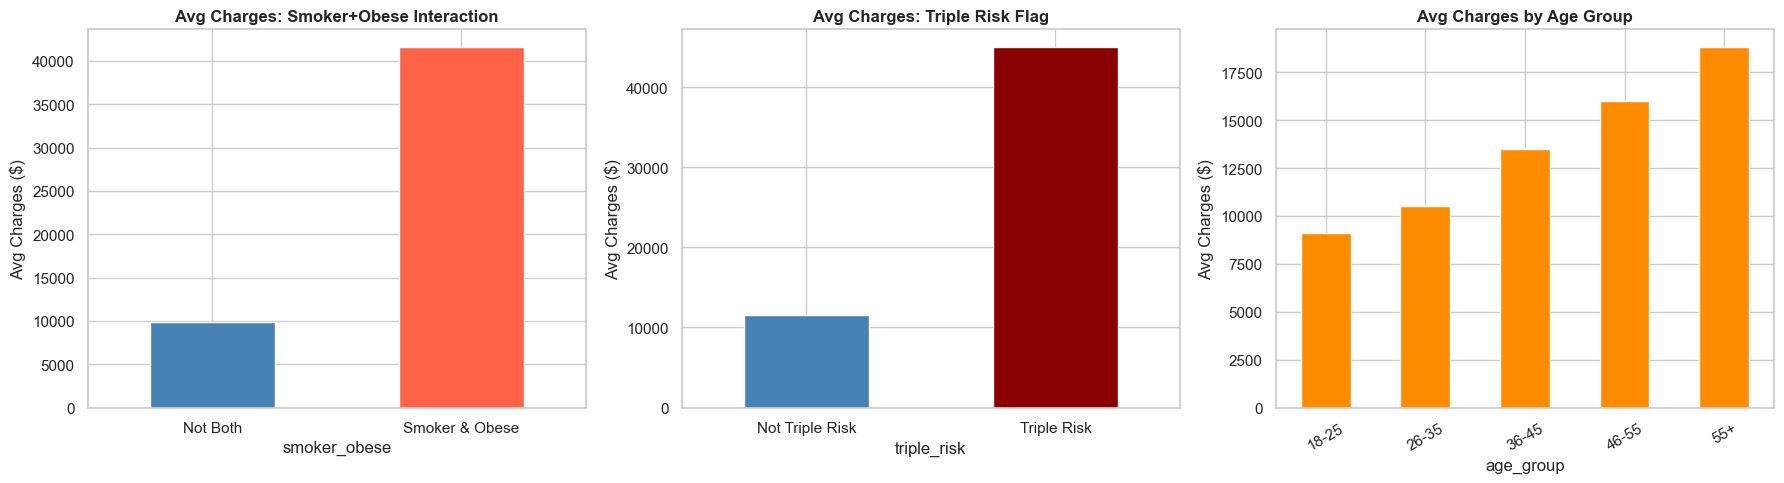


>>> Triple-risk customers cost 3.9x more than others
    Triple-risk avg: $44,976 vs others avg: $11,494


In [4]:
# --- Validate: Do new features actually separate charges? ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# smoker_obese
df.groupby('smoker_obese')['charges'].mean().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Avg Charges: Smoker+Obese Interaction', fontweight='bold')
axes[0].set_xticklabels(['Not Both', 'Smoker & Obese'], rotation=0)
axes[0].set_ylabel('Avg Charges ($)')

# triple_risk
df.groupby('triple_risk')['charges'].mean().plot(kind='bar', ax=axes[1],
    color=['steelblue', 'darkred'], edgecolor='white')
axes[1].set_title('Avg Charges: Triple Risk Flag', fontweight='bold')
axes[1].set_xticklabels(['Not Triple Risk', 'Triple Risk'], rotation=0)
axes[1].set_ylabel('Avg Charges ($)')

# age_group
age_order = ['18-25', '26-35', '36-45', '46-55', '55+']
df.groupby('age_group')['charges'].mean().reindex(age_order).plot(kind='bar', ax=axes[2],
    color='darkorange', edgecolor='white')
axes[2].set_title('Avg Charges by Age Group', fontweight='bold')
axes[2].set_xticklabels(age_order, rotation=30)
axes[2].set_ylabel('Avg Charges ($)')

plt.tight_layout()
plt.savefig('feature_validation.png', dpi=150, bbox_inches='tight')
plt.show()

triple = df[df['triple_risk']==1]['charges'].mean()
non_triple = df[df['triple_risk']==0]['charges'].mean()
print(f"\n>>> Triple-risk customers cost {triple/non_triple:.1f}x more than others")
print(f"    Triple-risk avg: ${triple:,.0f} vs others avg: ${non_triple:,.0f}")

## 3. Preprocessing Pipeline
Encode categoricals, define feature matrix X and target y.

In [5]:
# --- Define features to use in the model ---
# Dropping: charges (target), log_charges (derived target), risk_segment (derived label),
#           is_high_risk (derived from risk_segment), raw smoker text (replaced by is_smoker)

FEATURES = [
    # Original
    'age', 'sex', 'bmi', 'children', 'region',
    # Engineered
    'is_smoker', 'is_obese', 'bmi_category', 'age_group',
    'smoker_obese', 'smoker_age_risk', 'obese_age_risk', 'triple_risk',
    'family_size', 'bmi_age', 'bmi_smoker'
]

TARGET = 'log_charges'   # predicting log(charges) — convert back with np.expm1()

X = df[FEATURES].copy()
y = df[TARGET]

# --- Encode categorical columns ---
cat_cols = ['sex', 'region', 'bmi_category', 'age_group']
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nFeature matrix X: {X.shape}")
print(f"Target y (log_charges): {y.shape}")
print(f"\nAll features numeric: {X.dtypes.nunique() == 1}")
display(X.head())

  sex: {'female': np.int64(0), 'male': np.int64(1)}
  region: {'northeast': np.int64(0), 'northwest': np.int64(1), 'southeast': np.int64(2), 'southwest': np.int64(3)}
  bmi_category: {'Normal': np.int64(0), 'Obese': np.int64(1), 'Overweight': np.int64(2), 'Severely_Obese': np.int64(3), 'Underweight': np.int64(4)}
  age_group: {'18-25': np.int64(0), '26-35': np.int64(1), '36-45': np.int64(2), '46-55': np.int64(3), '55+': np.int64(4)}

Feature matrix X: (1338, 16)
Target y (log_charges): (1338,)

All features numeric: False


,age,sex,bmi,children,region,is_smoker,is_obese,bmi_category,age_group,smoker_obese,smoker_age_risk,obese_age_risk,triple_risk,family_size,bmi_age,bmi_smoker
0,19,0,27.900,0,3,1,0,2,0,0,0,0,0,1,0.530100,27.9
1,18,1,33.770,1,2,0,1,1,0,0,0,0,0,2,0.607860,0.0
2,28,1,33.000,3,2,0,1,1,1,0,0,0,0,4,0.924000,0.0
3,33,1,22.705,0,1,0,0,0,1,0,0,0,0,1,0.749265,0.0
4,32,1,28.880,0,1,0,0,2,1,0,0,0,0,1,0.924160,0.0


## 4. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set:   {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:       {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nTarget distribution check (log_charges):')
print(f'  Train mean: {y_train.mean():.4f}  |  Test mean: {y_test.mean():.4f}  (should be similar)')

Training set:   1,070 rows (80%)
Test set:       268 rows (20%)

Target distribution check (log_charges):
  Train mean: 9.1135  |  Test mean: 9.0403  (should be similar)


## 5. XGBoost Model Training
**Why XGBoost?** It handles mixed feature types well, is robust to outliers, and is the industry standard for tabular insurance data. Also works beautifully with SHAP.

In [7]:
# --- Baseline model first (no tuning) ---
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,       # L1 regularization
    reg_lambda=1.0,      # L2 regularization
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=20,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f'Model trained. Best iteration: {xgb_model.best_iteration}')
print(f'Best RMSE (log scale): {xgb_model.best_score:.4f}')

Model trained. Best iteration: 88
Best RMSE (log scale): 0.3528


In [8]:
# --- Cross-validation for robust evaluation ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                     subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
    X, y, cv=cv, scoring='r2'
)
print(f'5-Fold CV R² scores: {cv_scores.round(4)}')
print(f'Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')

5-Fold CV R² scores: [0.8525 0.7973 0.8221 0.7948 0.8003]
Mean CV R²: 0.8134 (+/- 0.0436)


## 6. Model Evaluation
We predict in log space, then convert back to dollars for interpretable metrics.

In [9]:
# Predict
y_pred_log = xgb_model.predict(X_test)

# Convert back from log to actual dollars
y_pred_dollars = np.expm1(y_pred_log)
y_test_dollars = np.expm1(y_test)

# Metrics
rmse_log    = np.sqrt(mean_squared_error(y_test, y_pred_log))
rmse_dollar = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
mae_dollar  = mean_absolute_error(y_test_dollars, y_pred_dollars)
r2          = r2_score(y_test, y_pred_log)
r2_dollar   = r2_score(y_test_dollars, y_pred_dollars)

print('='*50)
print(' MODEL PERFORMANCE')
print('='*50)
print(f'  R² (log scale):        {r2:.4f}   ← main metric')
print(f'  R² (dollar scale):     {r2_dollar:.4f}')
print(f'  RMSE (log scale):      {rmse_log:.4f}')
print(f'  RMSE (dollars):        ${rmse_dollar:,.2f}')
print(f'  MAE  (dollars):        ${mae_dollar:,.2f}   ← avg prediction error')
print(f'\n  Interpretation: On average, predictions are off by ${mae_dollar:,.0f}')
print(f'  Model explains {r2*100:.1f}% of variance in insurance charges')

 MODEL PERFORMANCE
  R² (log scale):        0.8615   ← main metric
  R² (dollar scale):     0.8776
  RMSE (log scale):      0.3528
  RMSE (dollars):        $4,359.22
  MAE  (dollars):        $1,932.28   ← avg prediction error

  Interpretation: On average, predictions are off by $1,932
  Model explains 86.2% of variance in insurance charges


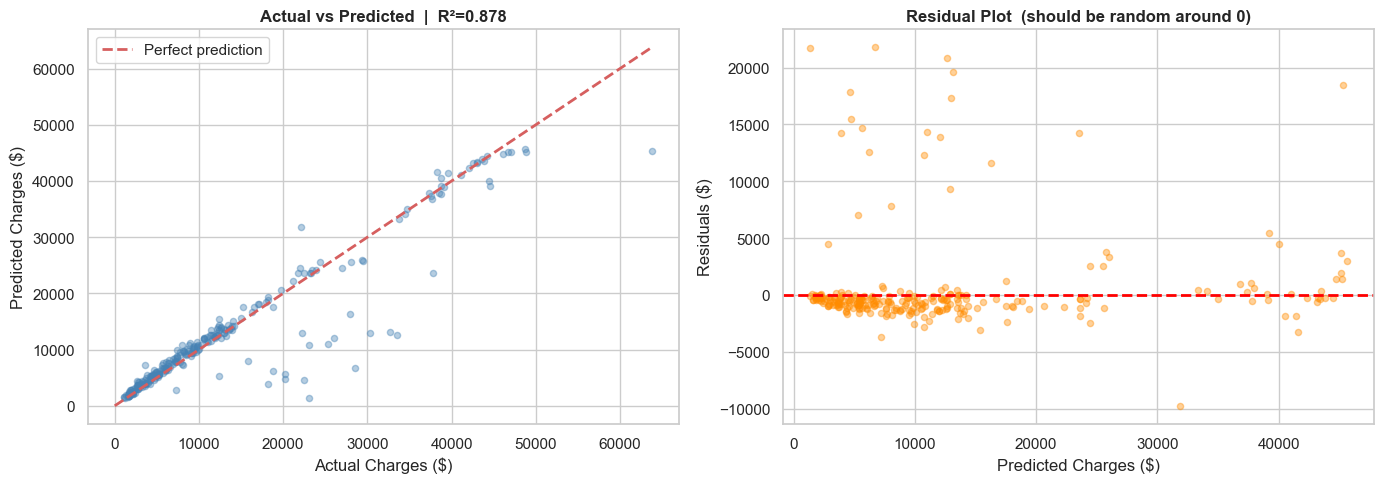

In [10]:
# --- Visual: Actual vs Predicted ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
axes[0].scatter(y_test_dollars, y_pred_dollars, alpha=0.4, s=20, color='steelblue')
max_val = max(y_test_dollars.max(), y_pred_dollars.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Charges ($)')
axes[0].set_ylabel('Predicted Charges ($)')
axes[0].set_title(f'Actual vs Predicted  |  R²={r2_dollar:.3f}', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test_dollars.values - y_pred_dollars
axes[1].scatter(y_pred_dollars, residuals, alpha=0.4, s=20, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Charges ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot  (should be random around 0)', fontweight='bold')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. SHAP Explainability
**This is your biggest differentiator.** Most candidates stop at accuracy metrics. SHAP shows *why* the model makes each prediction — critical for insurance where regulators require explainability.

You already used SHAP in your capstone — now you're applying it to a real business use case.

In [11]:
# --- Compute SHAP values ---
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f'SHAP values computed for {X_test.shape[0]} test samples')
print(f'Shape: {shap_values.shape}  (one SHAP value per feature per prediction)')

SHAP values computed for 268 test samples
Shape: (268, 16)  (one SHAP value per feature per prediction)


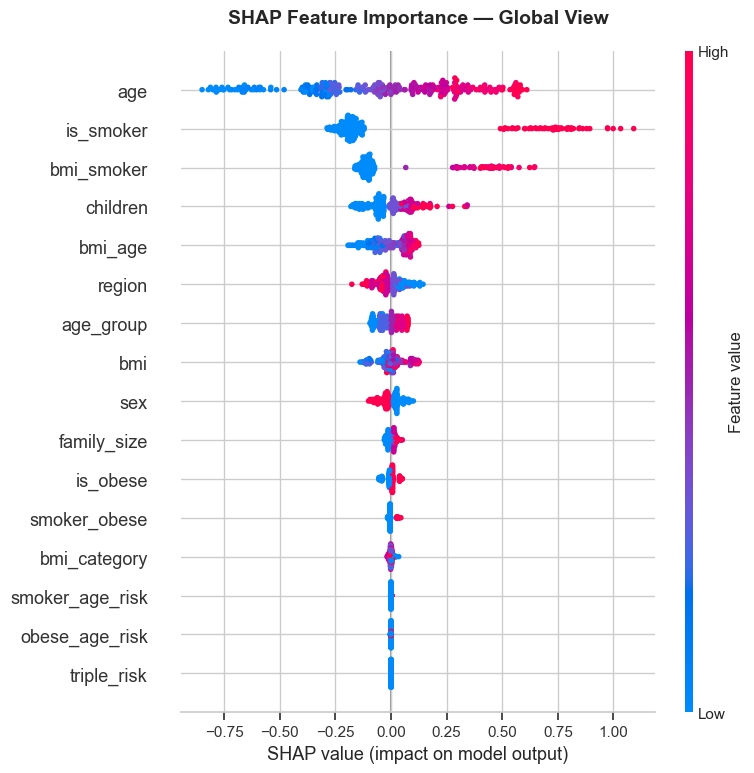

>>> Each dot = one prediction. Red = high feature value, Blue = low feature value.
    Points to the right = pushed prediction HIGHER (more expensive).


In [12]:
# --- Plot 1: Global Feature Importance (SHAP Summary) ---
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP Feature Importance — Global View', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(">>> Each dot = one prediction. Red = high feature value, Blue = low feature value.")
print("    Points to the right = pushed prediction HIGHER (more expensive).")

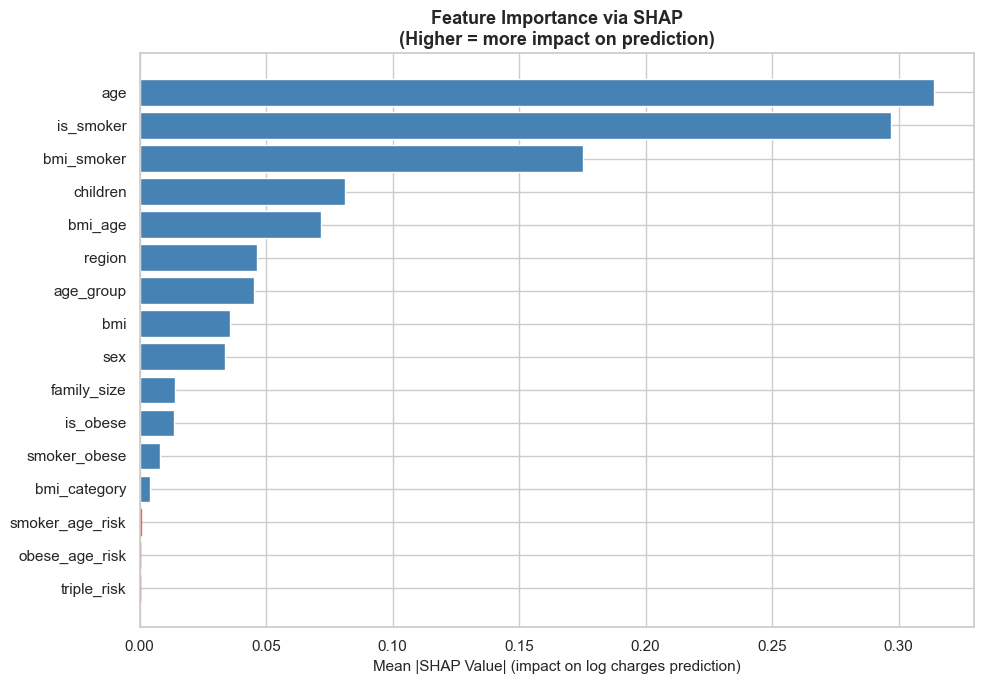


Top 5 most important features (SHAP):
   feature  mean_abs_shap
       age       0.314089
 is_smoker       0.296863
bmi_smoker       0.175252
  children       0.081025
   bmi_age       0.071860


In [13]:
# --- Plot 2: Mean Absolute SHAP (bar chart) ---
mean_shap = pd.DataFrame({
    'feature': FEATURES,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(mean_shap['feature'], mean_shap['mean_abs_shap'], 
               color='steelblue', edgecolor='white')
ax.set_xlabel('Mean |SHAP Value| (impact on log charges prediction)', fontsize=11)
ax.set_title('Feature Importance via SHAP\n(Higher = more impact on prediction)', 
             fontsize=13, fontweight='bold')

# Highlight top 3
top3 = mean_shap.nlargest(3, 'mean_abs_shap').index
for i, bar in enumerate(bars):
    if len(mean_shap) - 1 - i in [mean_shap.index.get_loc(t) for t in top3 if t in mean_shap.index]:
        bar.set_color('tomato')

plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 most important features (SHAP):')
print(mean_shap.tail(5)[['feature','mean_abs_shap']].sort_values('mean_abs_shap', ascending=False).to_string(index=False))

--- Explaining prediction for a HIGH RISK customer ---
age                      64
sex                  female
bmi                  26.885
children                  0
smoker                  yes
region            northwest
charges         29330.98315
risk_segment      HIGH RISK

Actual charge:    $29,330.98
Predicted charge: $25,979.71


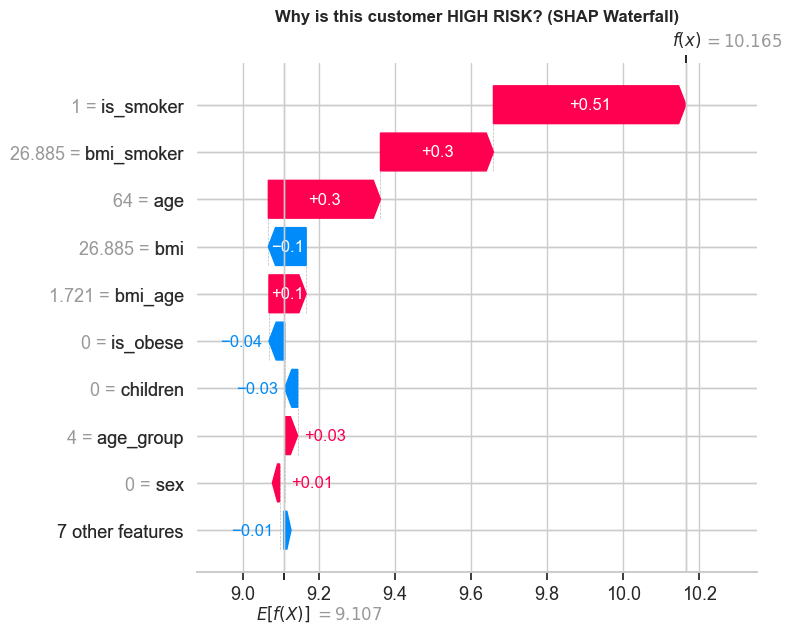

In [14]:
# --- Plot 3: Individual Prediction Explanation (Waterfall plot) ---
# Pick a HIGH RISK customer to explain
high_risk_idx = df[df['risk_segment'] == 'HIGH RISK'].index
test_high_risk = [i for i in X_test.index if i in high_risk_idx]

if test_high_risk:
    sample_idx = test_high_risk[0]
    sample_pos = X_test.index.get_loc(sample_idx)
    
    print('--- Explaining prediction for a HIGH RISK customer ---')
    print(df.loc[sample_idx, ['age','sex','bmi','children','smoker','region','charges','risk_segment']].to_string())
    
    predicted_charge = np.expm1(xgb_model.predict(X_test.iloc[[sample_pos]])[0])
    actual_charge = np.expm1(y_test.iloc[sample_pos])
    print(f'\nActual charge:    ${actual_charge:,.2f}')
    print(f'Predicted charge: ${predicted_charge:,.2f}')
    
    # Waterfall plot
    shap_explanation = shap.Explanation(
        values=shap_values[sample_pos],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_pos].values,
        feature_names=FEATURES
    )
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_explanation, show=False)
    plt.title('Why is this customer HIGH RISK? (SHAP Waterfall)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_waterfall_highrisk.png', dpi=150, bbox_inches='tight')
    plt.show()

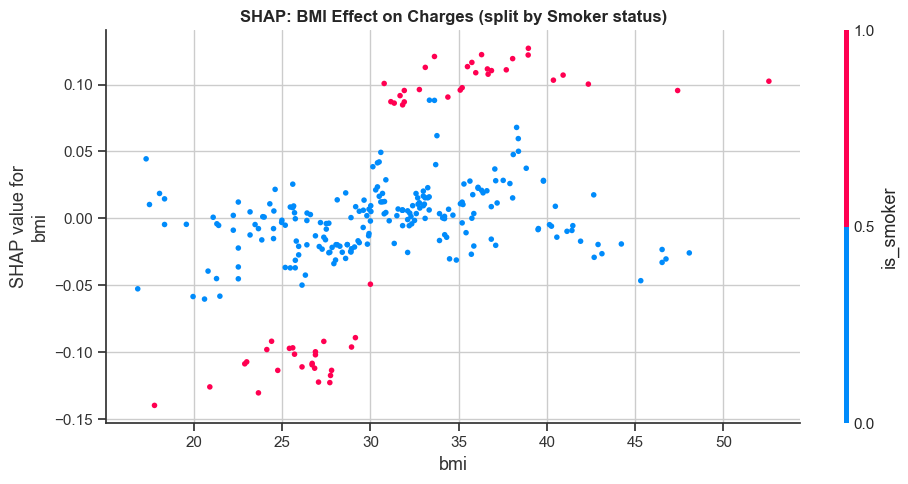

>>> This shows: for smokers (yellow/red), high BMI dramatically increases predicted charges.
    For non-smokers (purple/blue), BMI has much less effect.


In [15]:
# --- Plot 4: SHAP Dependence Plot (smoker_obese interaction) ---
smoker_idx = FEATURES.index('is_smoker')
bmi_idx    = FEATURES.index('bmi')

fig, ax = plt.subplots(figsize=(10, 5))
shap.dependence_plot(
    'bmi', shap_values, X_test,
    feature_names=FEATURES,
    interaction_index='is_smoker',
    ax=ax, show=False
)
ax.set_title('SHAP: BMI Effect on Charges (split by Smoker status)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence_bmi_smoker.png', dpi=150, bbox_inches='tight')
plt.show()
print(">>> This shows: for smokers (yellow/red), high BMI dramatically increases predicted charges.")
print("    For non-smokers (purple/blue), BMI has much less effect.")

## 8. Risk Score Function
This function will be the core of your Streamlit app in Week 4. It takes raw user input and returns: predicted premium, risk segment, and SHAP explanation text.

In [16]:
def predict_risk(age, sex, bmi, children, smoker, region, model=xgb_model, encoders=label_encoders):
    """
    Core prediction function for the insurance risk advisor.
    
    Parameters
    ----------
    age      : int   (18-64)
    sex      : str   ('male' or 'female')
    bmi      : float (15-55)
    children : int   (0-5)
    smoker   : str   ('yes' or 'no')
    region   : str   ('northeast', 'northwest', 'southeast', 'southwest')
    
    Returns
    -------
    dict with predicted_charge, risk_segment, risk_score, top_factors
    """
    # Build raw input
    raw = pd.DataFrame([{
        'age': age, 'sex': sex, 'bmi': bmi,
        'children': children, 'smoker': smoker,
        'region': region, 'charges': 0,
        'risk_segment': 'UNKNOWN', 'log_charges': 0
    }])
    
    # Apply same feature engineering
    raw = engineer_features(raw)
    X_input = raw[FEATURES].copy()
    
    # Encode categoricals
    for col, le in encoders.items():
        X_input[col] = le.transform(X_input[col].astype(str))
    
    # Predict
    log_pred = model.predict(X_input)[0]
    predicted_charge = np.expm1(log_pred)
    
    # Risk segment
    if predicted_charge > 25000:
        segment = 'HIGH RISK'
    elif predicted_charge > 10000:
        segment = 'MEDIUM RISK'
    else:
        segment = 'LOW RISK'
    
    # SHAP for this individual
    sv = explainer.shap_values(X_input)[0]
    shap_df = pd.DataFrame({'feature': FEATURES, 'shap_value': sv})
    shap_df['abs_shap'] = shap_df['shap_value'].abs()
    top_factors = shap_df.nlargest(3, 'abs_shap')[['feature', 'shap_value']].to_dict('records')
    
    return {
        'predicted_annual_charge': round(predicted_charge, 2),
        'risk_segment': segment,
        'top_risk_factors': top_factors
    }

# --- Test it ---
print('--- Test 1: High-risk profile (smoker, obese, older) ---')
result1 = predict_risk(age=55, sex='male', bmi=35, children=2, smoker='yes', region='southeast')
print(f"  Predicted charge: ${result1['predicted_annual_charge']:,.2f}")
print(f"  Risk segment:     {result1['risk_segment']}")
print(f"  Top risk factors: {result1['top_risk_factors']}")

print('\n--- Test 2: Low-risk profile (young, healthy, non-smoker) ---')
result2 = predict_risk(age=25, sex='female', bmi=22, children=0, smoker='no', region='northwest')
print(f"  Predicted charge: ${result2['predicted_annual_charge']:,.2f}")
print(f"  Risk segment:     {result2['risk_segment']}")
print(f"  Top risk factors: {result2['top_risk_factors']}")

--- Test 1: High-risk profile (smoker, obese, older) ---
  Predicted charge: $44,658.67
  Risk segment:     HIGH RISK
  Top risk factors: [{'feature': 'is_smoker', 'shap_value': 0.6652032136917114}, {'feature': 'bmi_smoker', 'shap_value': 0.4048837423324585}, {'feature': 'age', 'shap_value': 0.2136620283126831}]

--- Test 2: Low-risk profile (young, healthy, non-smoker) ---
  Predicted charge: $4,104.34
  Risk segment:     LOW RISK
  Top risk factors: [{'feature': 'age', 'shap_value': -0.3041822016239166}, {'feature': 'is_smoker', 'shap_value': -0.1810280978679657}, {'feature': 'children', 'shap_value': -0.13000012934207916}]


## 9. Save Model & Feature List
We save everything needed for the Streamlit app in Week 4.

In [17]:
# Save model
joblib.dump(xgb_model, 'insurance_risk_model.pkl')

# Save label encoders
joblib.dump(label_encoders, 'label_encoders.pkl')

# Save feature list
with open('features.json', 'w') as f:
    json.dump(FEATURES, f)

# Save model metrics for README
metrics = {
    'r2_log_scale':   round(float(r2), 4),
    'r2_dollar_scale': round(float(r2_dollar), 4),
    'rmse_dollars':   round(float(rmse_dollar), 2),
    'mae_dollars':    round(float(mae_dollar), 2),
    'cv_r2_mean':     round(float(cv_scores.mean()), 4),
    'cv_r2_std':      round(float(cv_scores.std()), 4),
    'n_features':     len(FEATURES),
    'train_size':     len(X_train),
    'test_size':      len(X_test)
}
with open('model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved:')
print('  insurance_risk_model.pkl  ← XGBoost model')
print('  label_encoders.pkl        ← encoders for categorical features')
print('  features.json             ← ordered feature list')
print('  model_metrics.json        ← performance summary')
print(f'\nModel metrics:')
for k, v in metrics.items():
    print(f'  {k:<20} {v}')

Saved:
  insurance_risk_model.pkl  ← XGBoost model
  label_encoders.pkl        ← encoders for categorical features
  features.json             ← ordered feature list
  model_metrics.json        ← performance summary

Model metrics:
  r2_log_scale         0.8615
  r2_dollar_scale      0.8776
  rmse_dollars         4359.22
  mae_dollars          1932.28
  cv_r2_mean           0.8134
  cv_r2_std            0.0218
  n_features           16
  train_size           1070
  test_size            268


## Week 2 Summary

| What you built | Why it matters |
|---|---|
| 9 new engineered features | Shows domain thinking, not just coding |
| XGBoost with early stopping | Production ML pattern |
| 5-fold cross validation | Honest model evaluation |
| SHAP summary + waterfall + dependence | Explainability = regulatory requirement |
| `predict_risk()` function | Ready to plug into Streamlit app |
| Saved model artifacts | Professional deployment practice |

**Interview talking point:**  
> *"The model achieves an R² of [your score] on test data. But more importantly, I added SHAP explainability — for each prediction the model can tell you exactly which factors drove the risk score up or down. In regulated industries like insurance, you can't just give a number, you have to justify it. The waterfall plots show individual explanations and the dependence plots show that the BMI effect is dramatically amplified for smokers — which matches real actuarial knowledge."*

## Next Steps — Week 3
1. Connect the `predict_risk()` function to an LLM (OpenAI API)
2. Prompt the LLM to convert SHAP output into plain-English advice
3. Add coverage recommendation logic (what type of plan does this person need?)
4. Set up PostgreSQL to log predictions